In [3]:
# --- Día 3: Análisis de Fragmentación ---
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set(style="whitegrid", context="talk")


In [4]:

# --- 1. Cargar resultados ---
base_path = "../experiments/results/metrics.csv"            # Deffuant clásico
coevo_path = "../experiments/results_coevo/metrics_coevo.csv"  # Coevolutivo

df_base = pd.read_csv(base_path)
df_coevo = pd.read_csv(coevo_path)


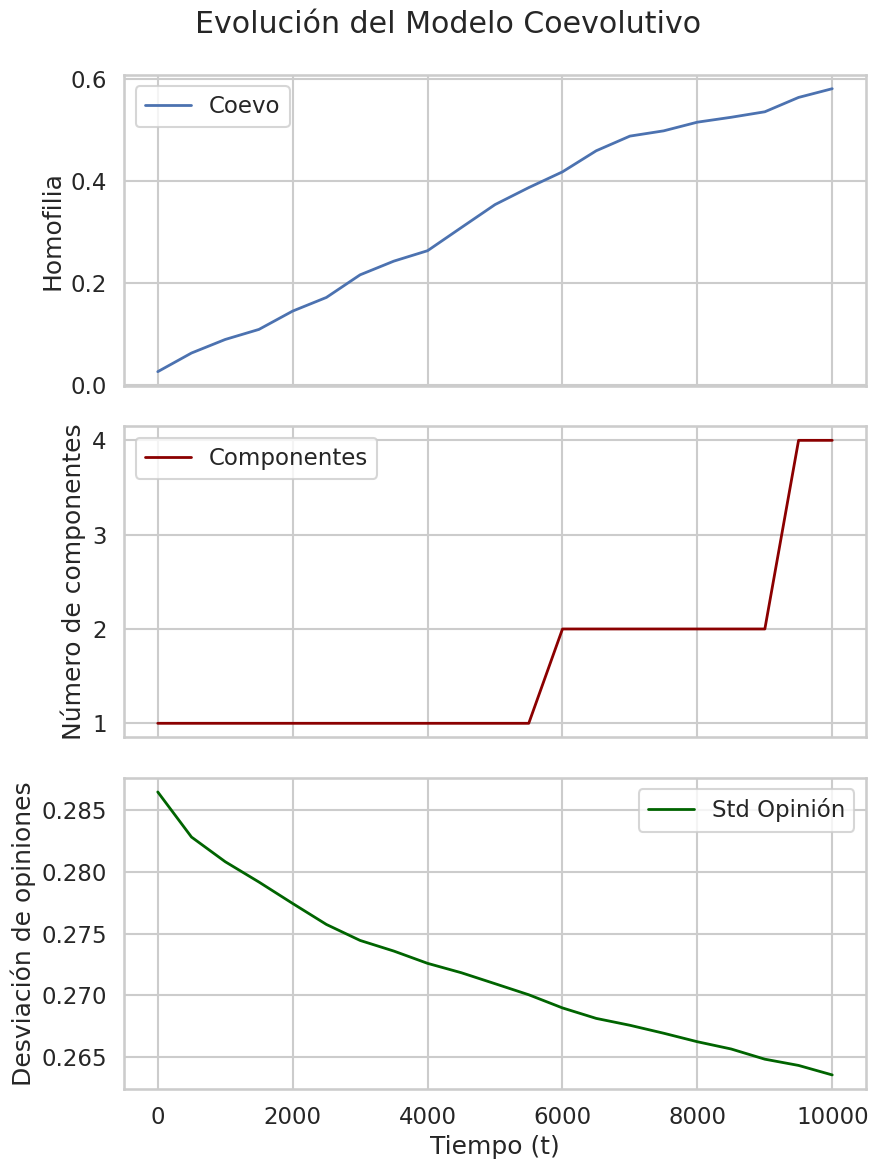

In [5]:

# --- 2. Graficar métricas ---
fig, axs = plt.subplots(3, 1, figsize=(9, 12), sharex=True)

axs[0].plot(df_coevo["t"], df_coevo["homophily"], label="Coevo", lw=2)
axs[0].set_ylabel("Homofilia")
axs[0].legend()

axs[1].plot(df_coevo["t"], df_coevo["n_components"], label="Componentes", lw=2, color="darkred")
axs[1].set_ylabel("Número de componentes")
axs[1].legend()

axs[2].plot(df_coevo["t"], df_coevo["std_opinion"], label="Std Opinión", lw=2, color="darkgreen")
axs[2].set_ylabel("Desviación de opiniones")
axs[2].set_xlabel("Tiempo (t)")
axs[2].legend()

plt.suptitle("Evolución del Modelo Coevolutivo")
plt.tight_layout()
plt.show()


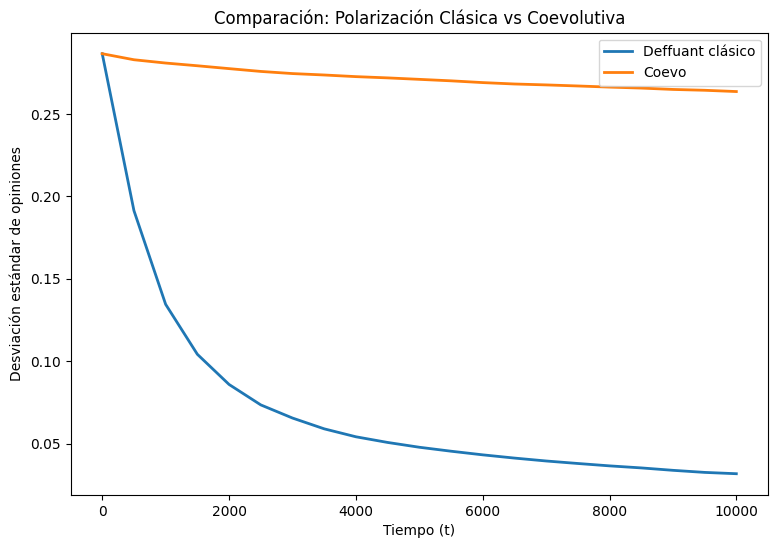

In [7]:

# --- 3. Comparar Deffuant clásico vs. Coevo ---
plt.figure(figsize=(9,6))
plt.plot(df_base["t"], df_base["std"], label="Deffuant clásico", lw=2)
plt.plot(df_coevo["t"], df_coevo["std_opinion"], label="Coevo", lw=2)
plt.xlabel("Tiempo (t)")
plt.ylabel("Desviación estándar de opiniones")
plt.title("Comparación: Polarización Clásica vs Coevolutiva")
plt.legend()
plt.show()


In [8]:

# --- 4. Detectar punto de ruptura ---
rupture_idx = (df_coevo["n_components"] > 1).idxmax()
rupture_time = df_coevo.loc[rupture_idx, "t"]
print(f"⏱ Punto estimado de ruptura: t ≈ {rupture_time}")


⏱ Punto estimado de ruptura: t ≈ 6000


In [9]:

# --- 5. Mostrar resumen final ---
print("Resumen final:")
print(df_coevo.tail(5))


Resumen final:
    n_components  frac_largest  homophily     t  mean_opinion  std_opinion
16             2         0.998   0.514549  8000      0.495681     0.266247
17             2         0.998   0.524105  8500      0.495681     0.265660
18             2         0.998   0.534879  9000      0.495681     0.264834
19             4         0.982   0.562951  9500      0.495681     0.264327
20             4         0.982   0.580034  9999      0.495681     0.263557
